In [3]:
import os
import json
import pandas as pd

# Define the path to evaluation_results folder
evaluation_results_path = "automated_underwater_area_estimation/evaluation_results"

# List to store all data
data = []

# Iterate through each dataset folder
for dataset_name in os.listdir(evaluation_results_path):
    dataset_path = os.path.join(evaluation_results_path, dataset_name)

    # Check if it's a directory
    if os.path.isdir(dataset_path):
        # Path to comparison folder and model_comparison.json
        comparison_path = os.path.join(dataset_path, "comparison", "model_comparison.json")

        # Check if model_comparison.json exists
        if os.path.exists(comparison_path):
            # Read the JSON file
            with open(comparison_path, 'r') as f:
                comparison_data = json.load(f)

            # Extract metrics for each model
            for comparison_line in comparison_data:
                row = comparison_line.copy()
                data.append(row)

# Create DataFrame
df = pd.DataFrame(data)
df


,model,dataset,dice_mean,dice_std,iou_mean,iou_std,precision_mean,precision_std,recall_mean,recall_std,pixel_accuracy_mean,pixel_accuracy_std
0,ReefSupport_yolov8_sm_latest,SEAFLOWER_BOLIVAR,0.639142,0.273579,0.525115,0.279690,0.623343,0.296739,0.784897,0.239981,0.799123,0.187836
1,ReefSupport_yolov8_xlarge_latest,SEAFLOWER_BOLIVAR,0.617834,0.293870,0.506807,0.285682,0.754451,0.274228,0.591918,0.304401,0.858348,0.129661
2,CoralSCOP,SEAFLOWER_BOLIVAR,0.410355,0.384473,0.345798,0.367516,0.949899,0.156843,0.351409,0.372370,0.824789,0.164629
3,EPFL_b2,SEAFLOWER_BOLIVAR,0.750383,0.232165,0.645239,0.245194,0.762752,0.209460,0.808452,0.245187,0.897571,0.097770
4,EPFL_b5,SEAFLOWER_BOLIVAR,0.743833,0.227179,0.636750,0.250775,0.705153,0.237249,0.857150,0.211971,0.888371,0.096113
5,ReefSupport_yolov8_sm_latest,SEAFLOWER_COURTOWN,0.524243,0.309691,0.413833,0.283088,0.590633,0.326399,0.593673,0.302388,0.858672,0.161305
6,ReefSupport_yolov8_xlarge_latest,SEAFLOWER_COURTOWN,0.453798,0.320880,0.351092,0.281308,0.633105,0.350152,0.423763,0.307123,0.886262,0.108033
7,CoralSCOP,SEAFLOWER_COURTOWN,0.094816,0.174315,0.061992,0.136490,0.924321,0.216763,0.063404,0.139496,0.833117,0.163683
8,EPFL_b2,SEAFLOWER_COURTOWN,0.544598,0.306380,0.432179,0.279181,0.655915,0.336681,0.523100,0.296859,0.908366,0.079883
9,EPFL_b5,SEAFLOWER_COURTOWN,0.572464,0.305791,0.462406,0.291262,0.678088,0.318009,0.567221,0.306093,0.912110,0.090375


In [37]:
df.drop(columns="dataset").groupby(["model"]).mean()
check = df['model'].str.replace('_yolov8', '').str.replace('_latest', '')
check

0         ReefSupport_sm
1     ReefSupport_xlarge
2              CoralSCOP
3                EPFL_b2
4                EPFL_b5
5         ReefSupport_sm
6     ReefSupport_xlarge
7              CoralSCOP
8                EPFL_b2
9                EPFL_b5
10        ReefSupport_sm
11    ReefSupport_xlarge
12             CoralSCOP
13               EPFL_b2
14               EPFL_b5
15        ReefSupport_sm
16    ReefSupport_xlarge
17             CoralSCOP
18               EPFL_b2
19               EPFL_b5
20        ReefSupport_sm
21    ReefSupport_xlarge
22             CoralSCOP
23               EPFL_b2
24               EPFL_b5
25        ReefSupport_sm
26    ReefSupport_xlarge
27             CoralSCOP
28               EPFL_b2
29               EPFL_b5
30        ReefSupport_sm
31    ReefSupport_xlarge
32             CoralSCOP
33               EPFL_b2
34               EPFL_b5
35        ReefSupport_sm
36    ReefSupport_xlarge
37             CoralSCOP
38               EPFL_b2
39               EPFL_b5


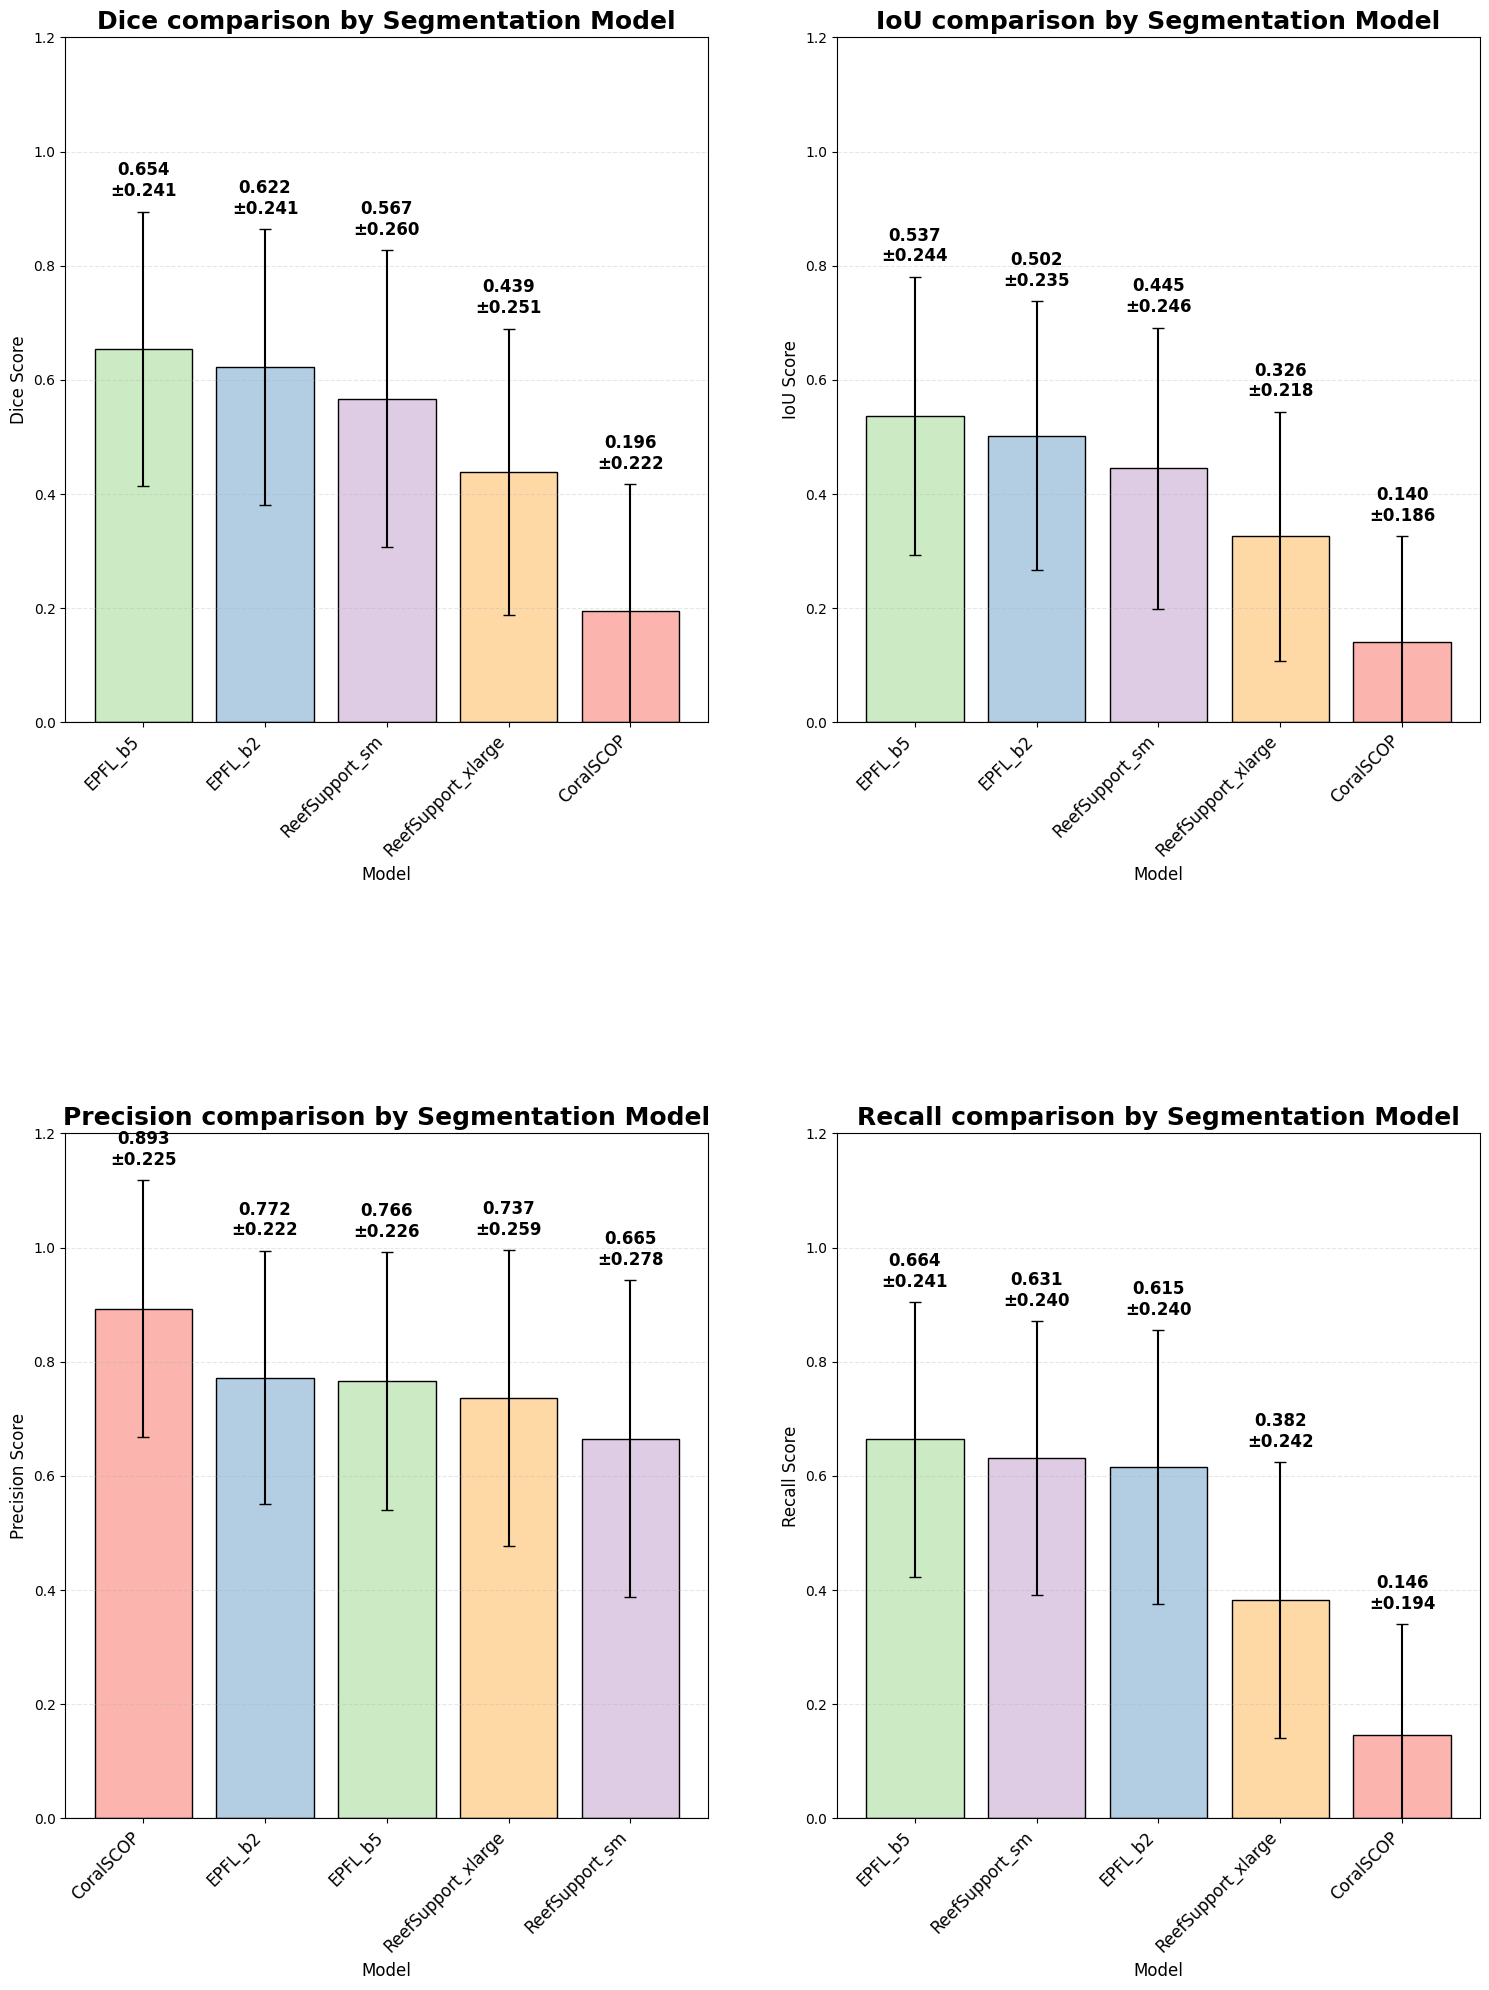

In [97]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate means and standard deviations grouped by model
df["model"] = df['model'].str.replace('_yolov8', '').str.replace('_latest', '')
df_grouped = df.drop(columns="dataset").groupby(["model"]).mean()

# Define metrics to plot
metrics = ['dice_mean', 'iou_mean', 'precision_mean', 'recall_mean']
metric_labels = ['Dice', 'IoU', 'Precision', 'Recall',]

# Get all unique models and assign consistent colors
all_models = df_grouped.index.tolist()
colors = plt.cm.Pastel1.colors[:len(all_models)]
model_colors = dict(zip(all_models, colors))

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 20))
axes = axes.flatten()

for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    # Get mean and std for the metric
    metric_data = df_grouped.copy()

    # Sort by mean (descending - best first)
    metric_data = metric_data.sort_values(metric, ascending=False)

    models = metric_data.index.tolist()
    means = metric_data[metric].values
    stds = metric_data[metric.replace("mean", "std")].values

    # Get colors for sorted models
    bar_colors = [model_colors[model] for model in models]

    # Plot bar chart
    ax = axes[idx]
    x_pos = np.arange(len(models))
    bars = ax.bar(x_pos, means, yerr=stds, capsize=4, color=bar_colors, edgecolor='black')

    # Add value labels on bars
    for i, (bar, mean, std) in enumerate(zip(bars, means, stds)):
        height = bar.get_height()
        # Position label above the error bar
        label_y = height + std + 0.02
        ax.text(bar.get_x() + bar.get_width()/2., label_y,
                f'{mean:.3f}\n±{std:.3f}',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    # Customize plot
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel(f'{label} Score', fontsize=12)
    ax.set_title(f'{label} comparison by Segmentation Model', fontsize=18, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=12)
    ax.set_ylim(0, 1.2)  # Increased to accommodate labels
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.axhline(y=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.subplots_adjust(hspace=0.6, wspace=0.2)
plt.savefig("./automated_underwater_area_estimation/evaluation_results/overall_comparison.png", dpi=300)
plt.show()